# Task 9 — The Stadium Panorama (Homography)

**Scenario:** two cameras cover a football field from different positions. They share a small overlapping area in the middle.

**Approach:** select 4 matching points found in both images, solve for the homography that projects camera 2's view into camera 1's coordinate space (same 8x8 linear-system approach as Task 8), then warp and stitch the two views into one seamless panorama.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)
np.set_printoptions(precision=3, suppress=True)

In [2]:
def compute_homography(src_pts, dst_pts):
    A = np.zeros((8, 8))
    b = np.zeros(8)
    for i in range(4):
        x, y = src_pts[i]
        xp, yp = dst_pts[i]
        A[2 * i]     = [x, y, 1, 0, 0, 0, -x * xp, -y * xp]
        A[2 * i + 1] = [0, 0, 0, x, y, 1, -x * yp, -y * yp]
        b[2 * i] = xp
        b[2 * i + 1] = yp
    h = np.linalg.solve(A, b)
    H = np.array([[h[0], h[1], h[2]],
                  [h[3], h[4], h[5]],
                  [h[6], h[7], 1.0]])
    return H

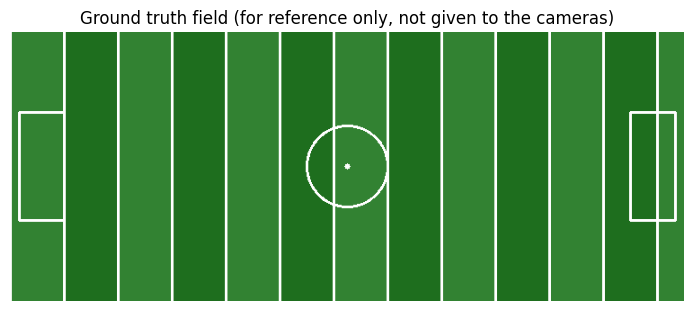

In [3]:
def make_field(w=750, h=300):
    img = np.full((h, w, 3), (40, 120, 40), dtype=np.uint8)
    for i, x in enumerate(range(0, w, 60)):
        shade = 10 if i % 2 == 0 else -10
        img[:, x:x + 60] = np.clip(img[:, x:x + 60].astype(int) + shade, 0, 255).astype(np.uint8)
        cv2.line(img, (x, 0), (x, h), (255, 255, 255), 2)
    cv2.circle(img, (w // 2, h // 2), 45, (255, 255, 255), 2)
    cv2.circle(img, (w // 2, h // 2), 3, (255, 255, 255), -1)
    cv2.rectangle(img, (10, h // 2 - 60), (60, h // 2 + 60), (255, 255, 255), 2)
    cv2.rectangle(img, (w - 60, h // 2 - 60), (w - 10, h // 2 + 60), (255, 255, 255), 2)
    return img

field = make_field()
cv2.imwrite('data_field_truth.png', field)
fw, fh = field.shape[1], field.shape[0]

plt.figure(figsize=(9, 3.5))
plt.imshow(cv2.cvtColor(field, cv2.COLOR_BGR2RGB))
plt.title('Ground truth field (for reference only, not given to the cameras)')
plt.axis('off')
plt.savefig('output/00_ground_truth.png', bbox_inches='tight', dpi=150)
plt.show()

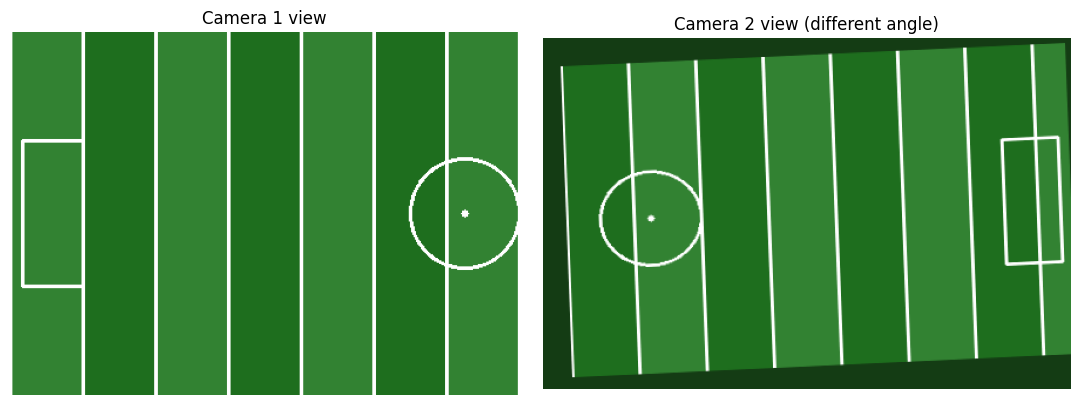

In [4]:
cam1_view = field[:, 0:420].copy()

cam2_crop = field[:, 300:750].copy()
ch, cw = cam2_crop.shape[:2]
src_tri = np.float32([[0, 0], [cw, 0], [0, ch]])
dst_tri = np.float32([[15, 25], [cw - 5, 5], [25, ch - 10]])
true_H_cam2_distort = cv2.getAffineTransform(src_tri, dst_tri)
cam2_view = cv2.warpAffine(cam2_crop, true_H_cam2_distort, (cw, ch), borderValue=(20, 60, 20))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(cv2.cvtColor(cam1_view, cv2.COLOR_BGR2RGB))
axes[0].set_title('Camera 1 view')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(cam2_view, cv2.COLOR_BGR2RGB))
axes[1].set_title('Camera 2 view (different angle)')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('output/01_two_cameras.png', bbox_inches='tight', dpi=150)
plt.show()

4 matching points, camera 1 coords:
 [[300.  90.]
 [420.  90.]
 [420. 210.]
 [300. 210.]]
4 matching points, camera 2 coords:
 [[ 18.    104.5  ]
 [132.667  99.167]
 [136.667 205.167]
 [ 22.    210.5  ]]


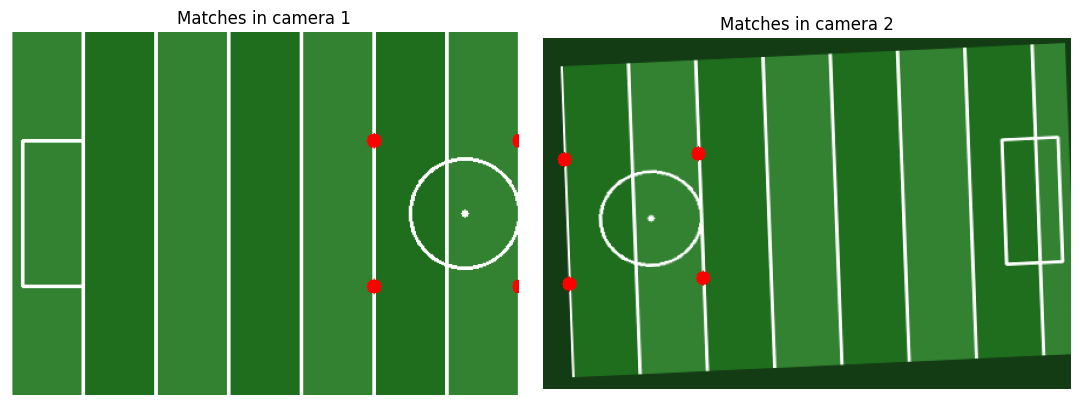

In [5]:
pts_field = np.float32([[300, 90], [420, 90], [420, 210], [300, 210]])

pts_cam1 = pts_field - np.array([0, 0])

pts_in_crop = pts_field - np.array([300, 0])
ones = np.ones((4, 1))
pts_cam2 = (true_H_cam2_distort @ np.hstack([pts_in_crop, ones]).T).T

print('4 matching points, camera 1 coords:\n', pts_cam1)
print('4 matching points, camera 2 coords:\n', pts_cam2)

annotated1 = cam1_view.copy()
annotated2 = cam2_view.copy()
for (x, y) in pts_cam1:
    cv2.circle(annotated1, (int(x), int(y)), 6, (0, 0, 255), -1)
for (x, y) in pts_cam2:
    cv2.circle(annotated2, (int(x), int(y)), 6, (0, 0, 255), -1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(cv2.cvtColor(annotated1, cv2.COLOR_BGR2RGB))
axes[0].set_title('Matches in camera 1')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(annotated2, cv2.COLOR_BGR2RGB))
axes[1].set_title('Matches in camera 2')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('output/02_matches.png', bbox_inches='tight', dpi=150)
plt.show()

Homography projecting camera 2 into camera 1 space, H =
 [[  1.045  -0.039 285.315]
 [  0.053   1.13  -29.041]
 [  0.     -0.      1.   ]]


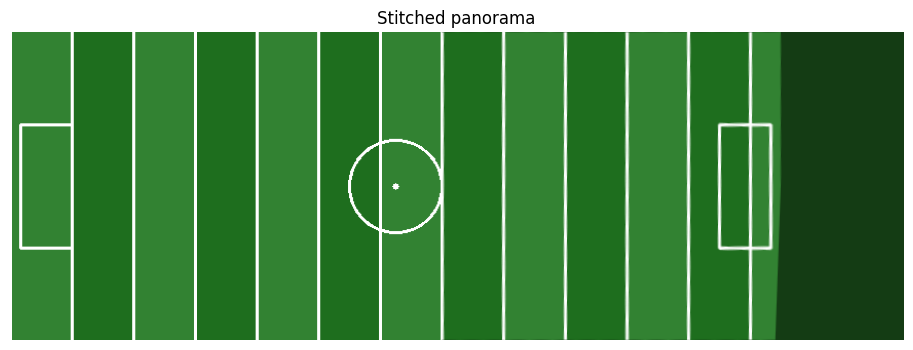

In [6]:
H = compute_homography(pts_cam2, pts_cam1)
print('Homography projecting camera 2 into camera 1 space, H =\n', H)

pano_w, pano_h = cam1_view.shape[1] + cam2_view.shape[1], cam1_view.shape[0]
warped_cam2 = cv2.warpPerspective(cam2_view, H, (pano_w, pano_h), borderValue=(20, 60, 20))

panorama = warped_cam2.copy()
panorama[:, :cam1_view.shape[1]] = cam1_view

nonzero_cols = np.where(panorama.sum(axis=(0, 2)) > 0)[0]
panorama = panorama[:, :nonzero_cols.max() + 1]

plt.figure(figsize=(12, 4))
plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
plt.title('Stitched panorama')
plt.axis('off')
plt.savefig('output/03_panorama.png', bbox_inches='tight', dpi=150)
plt.show()